In [173]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, levene, mannwhitneyu, shapiro, ttest_ind

import numpy as np

warnings.filterwarnings("ignore")

DATA_PATH = Path("./data/ai4i2020.csv")

In [174]:
def set_eda_style():
    sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")

    plt.rcParams.update(
        {
            # Taille des figures
            "figure.figsize": (8, 5),
            "figure.dpi": 110,
            # Titres et labels
            "axes.titlesize": 14,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
            "axes.labelweight": "regular",
            # Axes
            "axes.edgecolor": "#333333",
            "axes.linewidth": 0.8,
            # Grille
            "grid.color": "#DDDDDD",
            "grid.linestyle": "-",
            "grid.linewidth": 0.6,
            # Ticks
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            # Légendes
            "legend.fontsize": 10,
            "legend.frameon": False,
            # Police
            "font.family": "sans-serif",
            # Couleurs texte
            "text.color": "#333333",
            "axes.labelcolor": "#333333",
            "xtick.color": "#333333",
            "ytick.color": "#333333",
        }
    )


set_eda_style()

# Chargement des données

In [175]:
df = pd.read_csv(DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

# Analyse des features

In [177]:
categorical_feature = ["Type"]
numerical_feature = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
features_names = categorical_feature + numerical_feature
features = df[features_names]

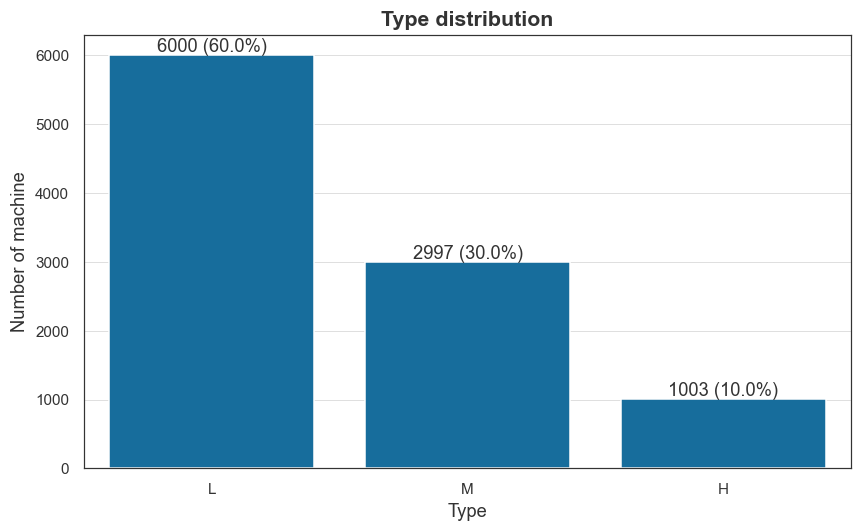

In [178]:
type_distribution = features["Type"].value_counts()
type_distribution_percentages = type_distribution / type_distribution.sum() * 100

plt.figure()
barplot = sns.barplot(
    x=type_distribution.index,
    y=type_distribution.values,
)

for i, (count, pct) in enumerate(
    zip(type_distribution.values, type_distribution_percentages.values)
):
    barplot.text(i, count, f"{count} ({pct:.1f}%)", ha="center", va="bottom")

plt.xlabel("Type")
plt.ylabel("Number of machine")
plt.title("Type distribution")
plt.tight_layout()
plt.show()

* Répartition déséquilibré des types de machines.

In [179]:
def plot_distribution_and_outliers(data, column):
    x = data[column].dropna()

    mean = x.mean()
    std = x.std()

    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1

    lower_tukey = q1 - 1.5 * iqr
    upper_tukey = q3 + 1.5 * iqr

    outliers_tukey = x[(x < lower_tukey) | (x > upper_tukey)]

    lower_sigma = mean - 3 * std
    upper_sigma = mean + 3 * std

    outliers_sigma = x[(x < lower_sigma) | (x > upper_sigma)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(x, bins=30, kde=True, ax=axes[0])

    axes[0].axvline(mean, color="red", linestyle="--", label=f"Mean = {mean:.2f}")
    axes[0].axvline(
        mean + std, color="orange", linestyle="--", label=f"+1σ = {mean + std:.2f}"
    )
    axes[0].axvline(
        mean - std, color="orange", linestyle="--", label=f"-1σ = {mean - std:.2f}"
    )

    axes[0].set_title(f"Distribution of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    sns.boxplot(x=x, ax=axes[1])

    axes[1].scatter(
        outliers_tukey,
        np.zeros_like(outliers_tukey),
        color="red",
        label=f"Tukey outliers ({len(outliers_tukey)})",
        zorder=3,
    )

    axes[1].scatter(
        outliers_sigma,
        np.zeros_like(outliers_sigma) + 0.02,
        color="purple",
        label=f"3σ outliers ({len(outliers_sigma)})",
        zorder=3,
    )

    axes[1].set_title(f"Boxplot of {column}")
    axes[1].set_xlabel(column)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

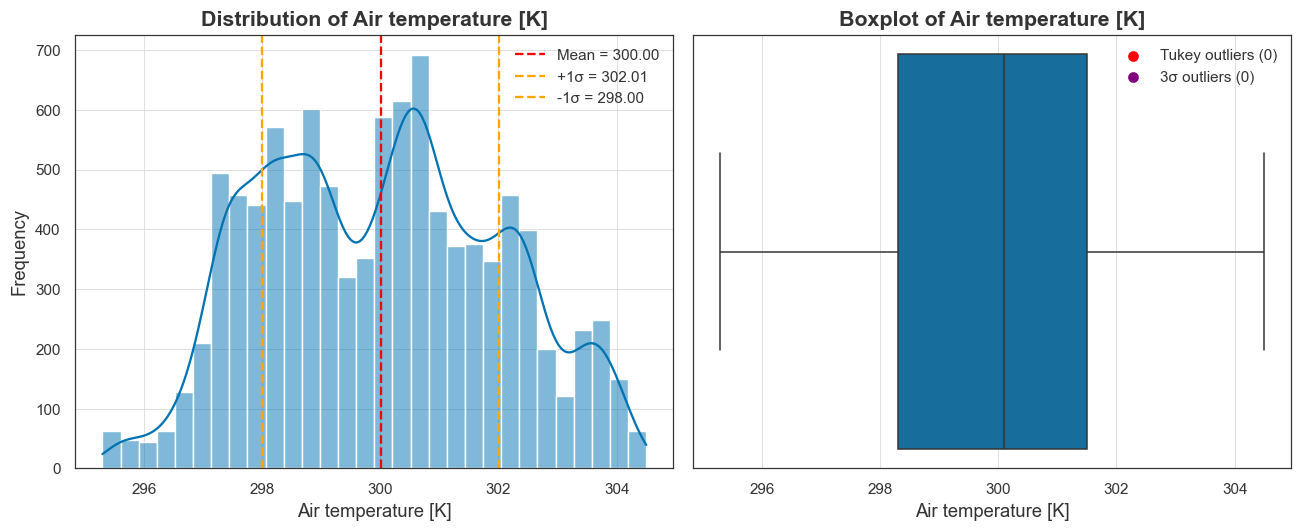

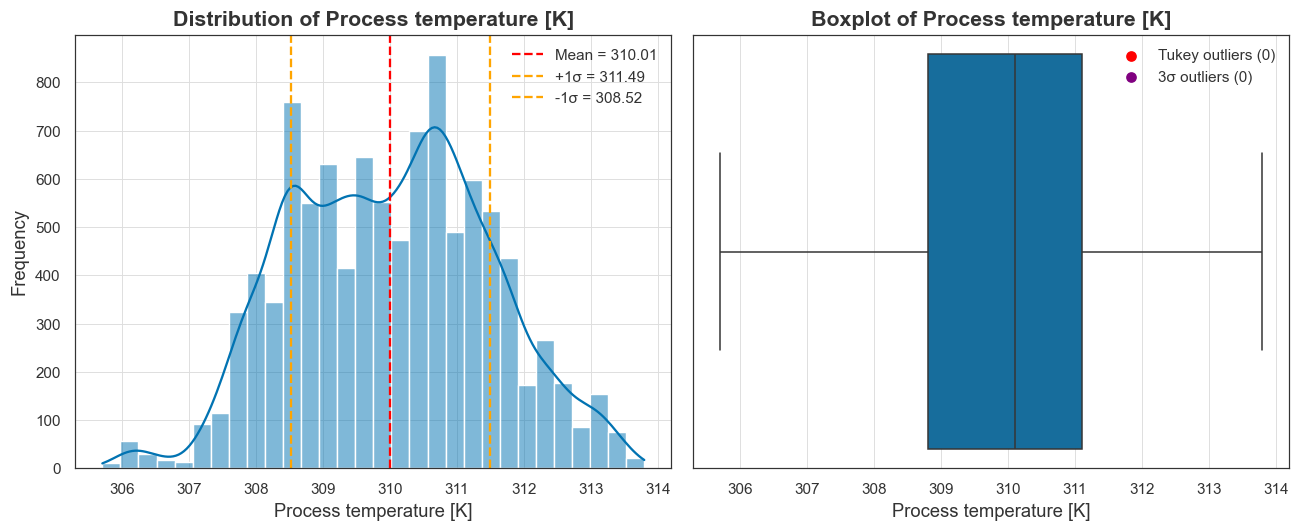

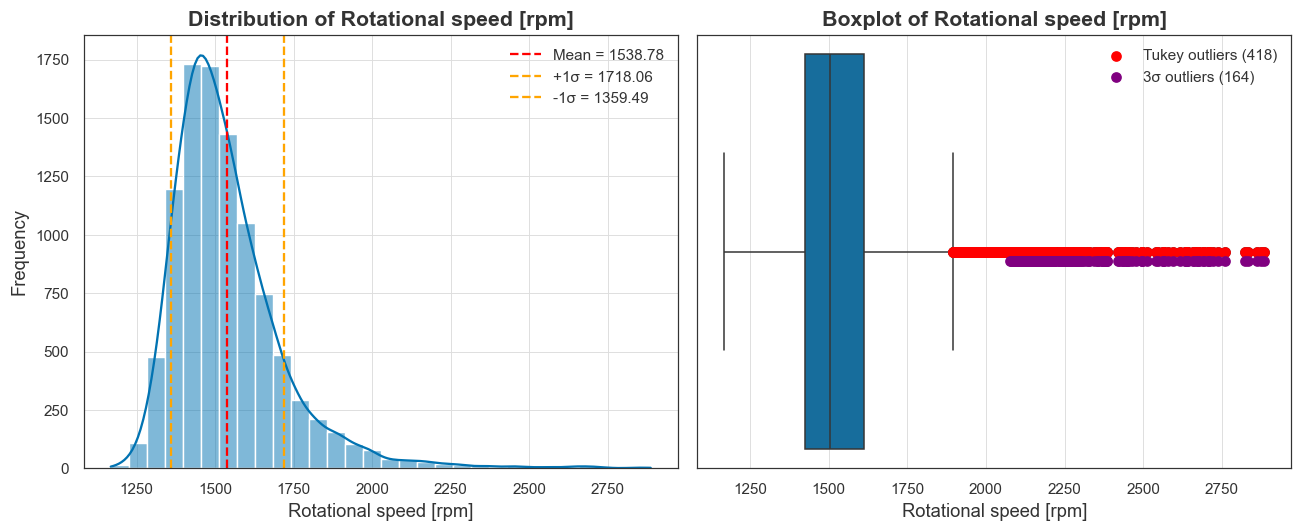

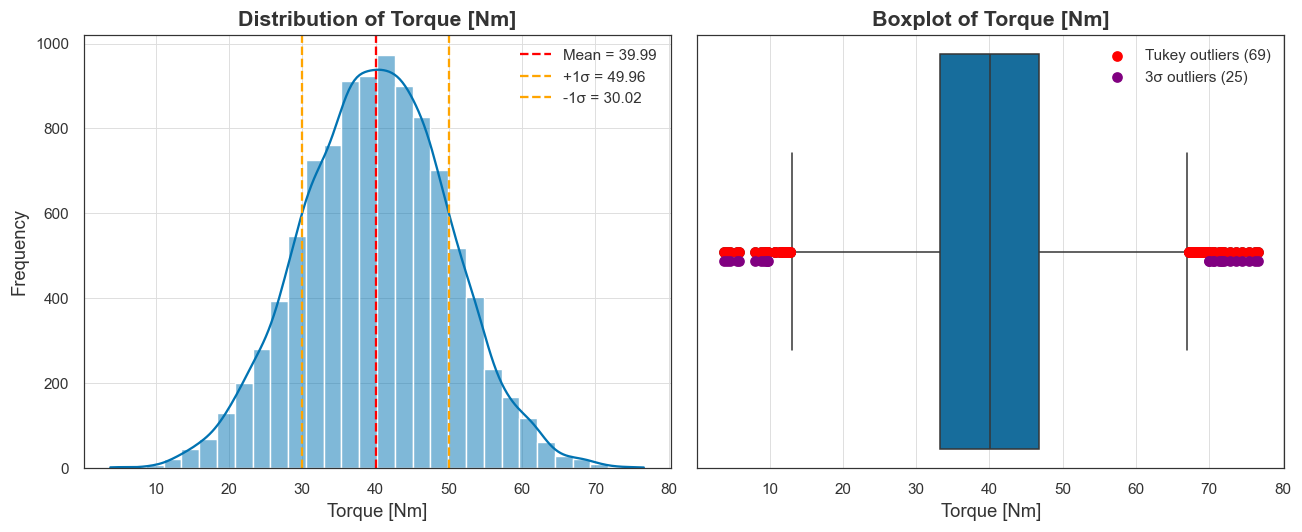

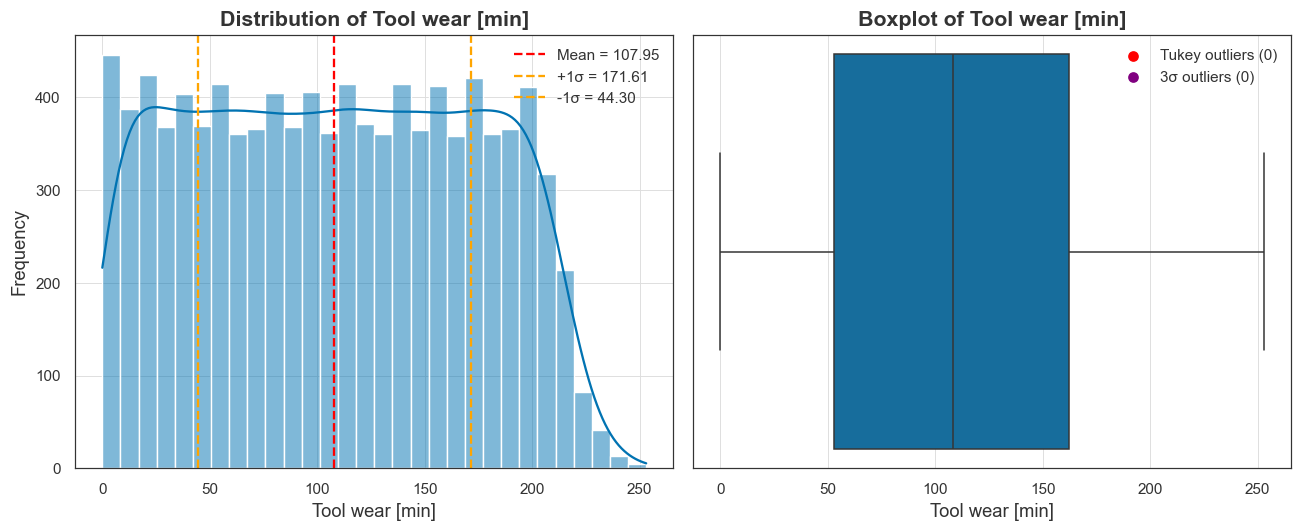

In [180]:
for feature_name in numerical_feature:
    plot_distribution_and_outliers(df, feature_name)

In [181]:
def plot_correlation_matrix(
    df,
    method="pearson",
    figsize=(10, 8),
    annot=True,
    cmap="coolwarm",
    target=None,
    mask_upper=True,
):
    num_df = df.select_dtypes(include=np.number)

    if num_df.shape[1] < 2:
        raise ValueError(
            "Pas assez de variables numériques pour calculer une corrélation."
        )

    corr = num_df.corr(method=method)

    if target and target in corr.columns:
        corr = corr[[target]].sort_values(by=target, ascending=False)

    mask = None
    if mask_upper and target is None:
        mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=figsize)

    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        annot=annot,
        fmt=".2f",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )

    title = f"Correlation matrix ({method})"
    if target:
        title = f"Correlation with target: {target} ({method})"

    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [182]:
def add_one_hot_columns(df, column):
    df = df.copy()
    dummies = pd.get_dummies(df[column], prefix=column).astype(int)
    df = pd.concat([df, dummies], axis=1).drop(columns=column)
    return df


features_one_hot = add_one_hot_columns(features, categorical_feature[0])
features_one_hot.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


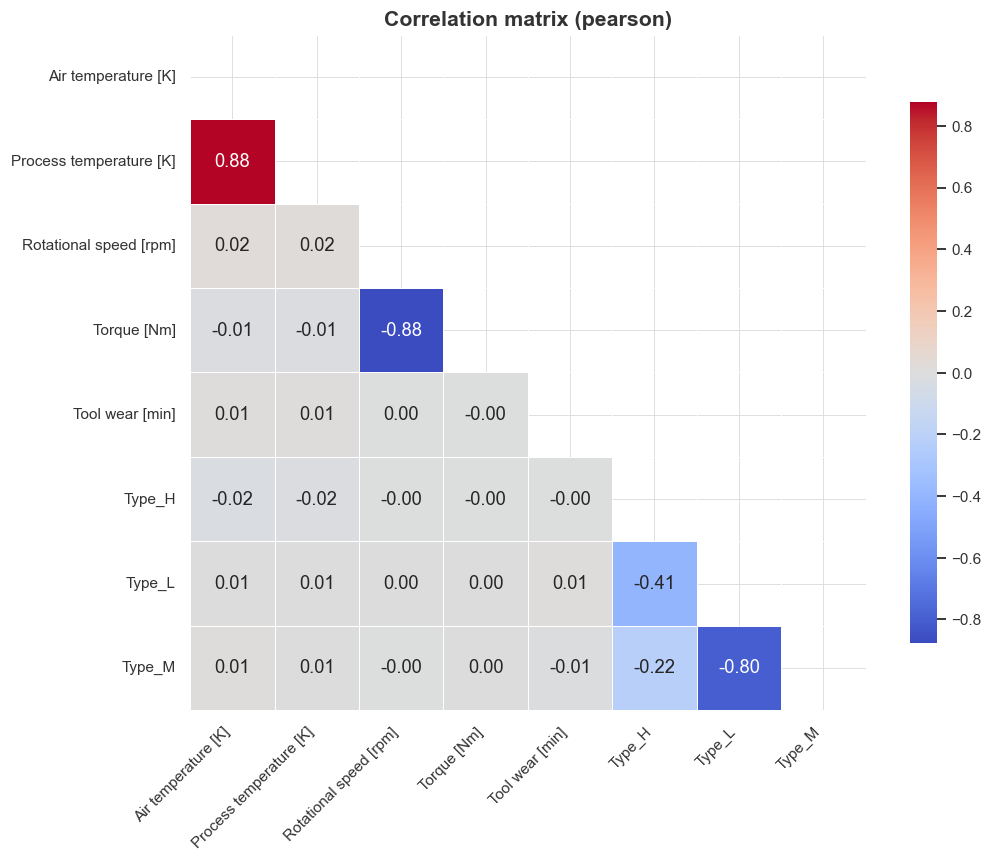

In [183]:
plot_correlation_matrix(features_one_hot, method="pearson")

* Forte corrélation positive entre `Process temperature [K]` et `Air temperature [K]`.
* Forte corrélation négative entre `Torque [Nm]` et `Rotation speed [rpm]`.
* Forte corrélation négative entre `Type_M` et `Type_L`.

# Analyse de la target

In [184]:
target_name = "Machine failure"
target = df[target_name]

classes_names = ["OK", "Failure"]

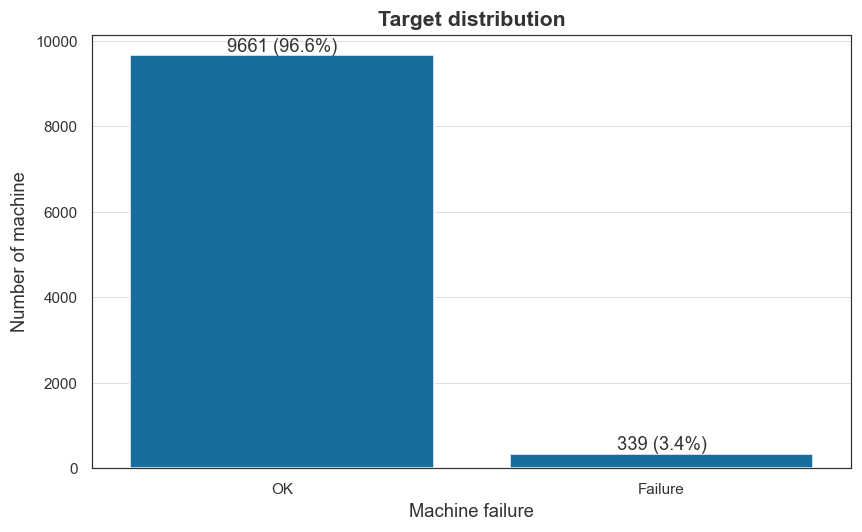

In [185]:
target_distribution = target.value_counts()
target_distribution_percentages = target_distribution / target_distribution.sum() * 100

plt.figure()
barplot = sns.barplot(
    x=target_distribution.index,
    y=target_distribution.values,
)

for i, (count, pct) in enumerate(
    zip(target_distribution.values, target_distribution_percentages.values)
):
    barplot.text(i, count, f"{count} ({pct:.1f}%)", ha="center", va="bottom")

plt.xlabel(target_name)
plt.xticks(range(len(classes_names)), classes_names)
plt.ylabel("Number of machine")
plt.title("Target distribution")
plt.tight_layout()
plt.show()

* Grand déséquilibre des classes.

In [186]:
def plot_target_numerical_feature_correlations(df, target, method="pearson"):
    data = df.select_dtypes(include=np.number).copy()

    if target not in data.columns:
        raise ValueError("La target doit être numérique et présente dans le DataFrame.")

    corr = data.corr(method=method)[target].drop(target)

    corr = corr.sort_values(key=np.abs, ascending=False)

    plt.figure(figsize=(8, 5))

    sns.barplot(x=corr.values, y=corr.index, palette="coolwarm")

    plt.axvline(0, color="black", linewidth=1)

    plt.title(f"Correlation between features and target ({method})")
    plt.xlabel("Correlation coefficient")
    plt.ylabel("Features")

    plt.tight_layout()
    plt.show()

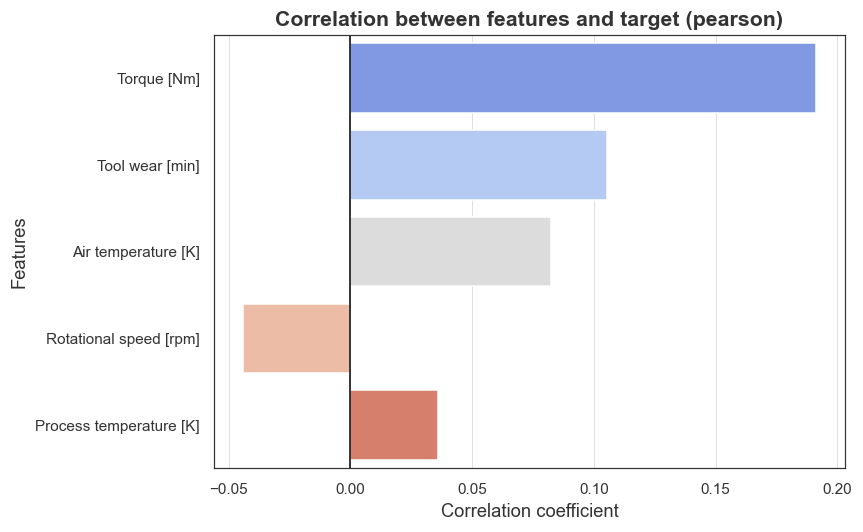

In [187]:
plot_target_numerical_feature_correlations(
    df[numerical_feature + [target_name]], target_name
)

In [188]:
def plot_target_categorical_feature_correlations(df, target):
    if target not in df.columns:
        raise ValueError("La target doit être présente dans le DataFrame.")

    def cramers_v(confusion_matrix):
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        r, k = confusion_matrix.shape
        return np.sqrt(chi2 / (n * (min(r, k) - 1)))

    cat_df = df.select_dtypes(exclude=np.number).copy()

    results = {}

    for col in cat_df.columns:
        if col == target:
            continue

        contingency = pd.crosstab(df[col], df[target])

        # éviter cas dégénérés
        if contingency.shape[0] < 2:
            continue

        results[col] = cramers_v(contingency)

    results = pd.Series(results).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))

    sns.barplot(x=results.values, y=results.index, palette="viridis")

    plt.axvline(0, color="black", linewidth=1)

    plt.title("Association between categorical features and target (Cramér's V)")
    plt.xlabel("Cramér's V (0 = no association, 1 = strong)")
    plt.ylabel("Features")

    plt.tight_layout()
    plt.show()

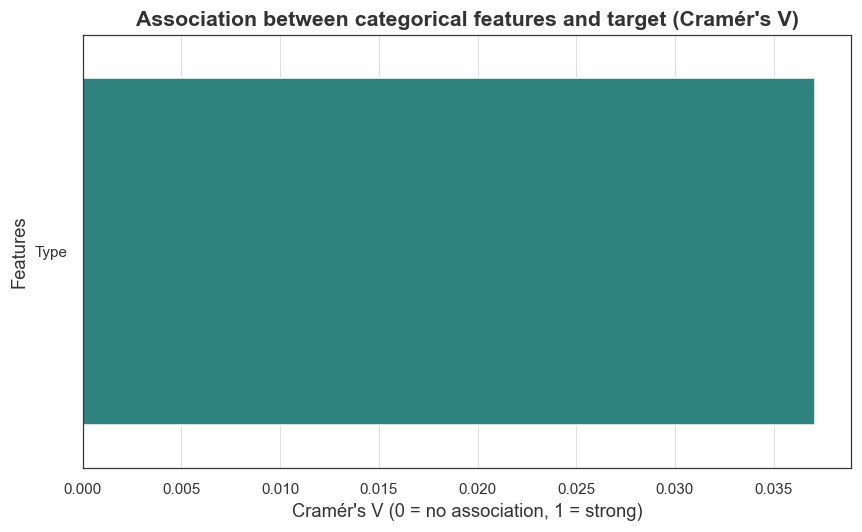

In [189]:
plot_target_categorical_feature_correlations(
    df[categorical_feature + [target_name]], target_name
)

In [190]:
def plot_categorical_feature_vs_target(df, feature, target):
    data = df[[feature, target]].dropna()

    counts = pd.crosstab(data[feature], data[target])

    counts_long = counts.reset_index().melt(
        id_vars=feature, var_name=target, value_name="count"
    )

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=counts_long, x=feature, y="count", hue=target)

    for i, feature_cat in enumerate(counts.index):
        total = counts.loc[feature_cat].sum()

        for j, target_class in enumerate(counts.columns):
            count = counts.loc[feature_cat, target_class]
            pct = (count / total) * 100

            if count > 0:
                ax.text(
                    i + (j - 0.5) * 0.4,
                    count,
                    f"{count} ({pct:.1f}%)",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

    plt.title(f"{feature} distribution by {target}")
    plt.ylabel("Count")
    plt.xlabel(feature)
    plt.legend(title=target)
    plt.tight_layout()
    plt.show()

In [191]:
def plot_numerical_feature_vs_target(df, feature, target):
    data = df[[feature, target]].dropna()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(
        data=data,
        x=feature,
        hue=target,
        bins=30,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
    )
    plt.title(f"{feature} distribution by {target}")

    plt.subplot(1, 2, 2)
    sns.boxplot(data=data, x=target, y=feature)
    plt.title(f"{feature} vs {target}")

    plt.tight_layout()
    plt.show()

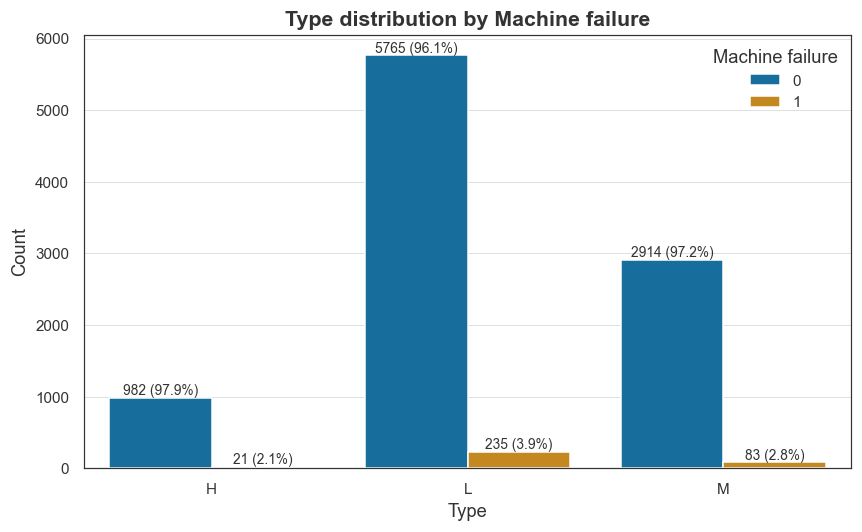

In [192]:
plot_categorical_feature_vs_target(df, categorical_feature[0], target_name)

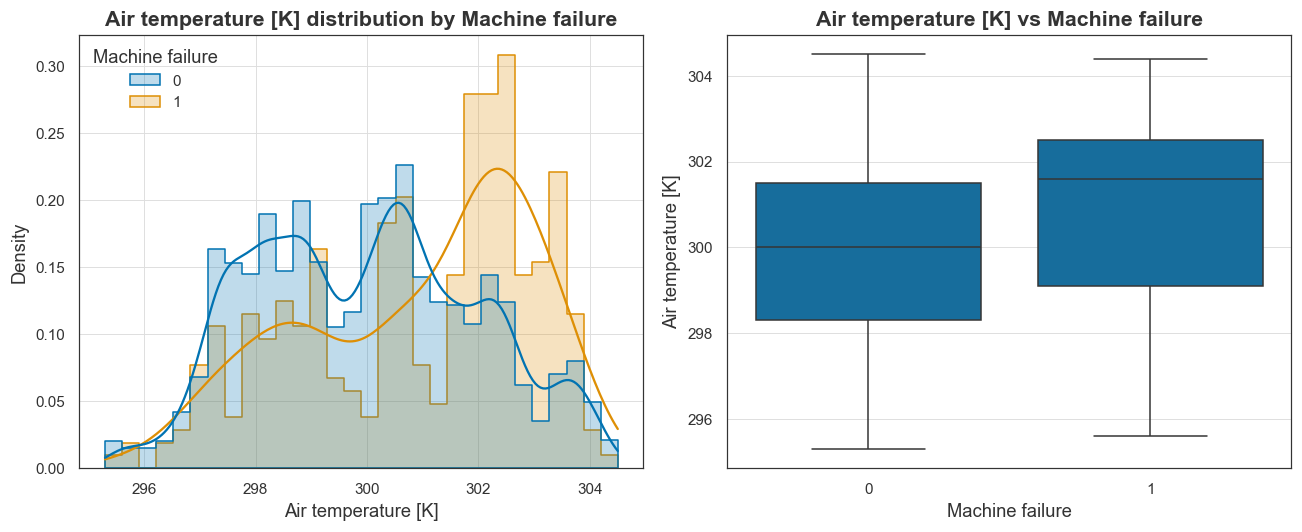

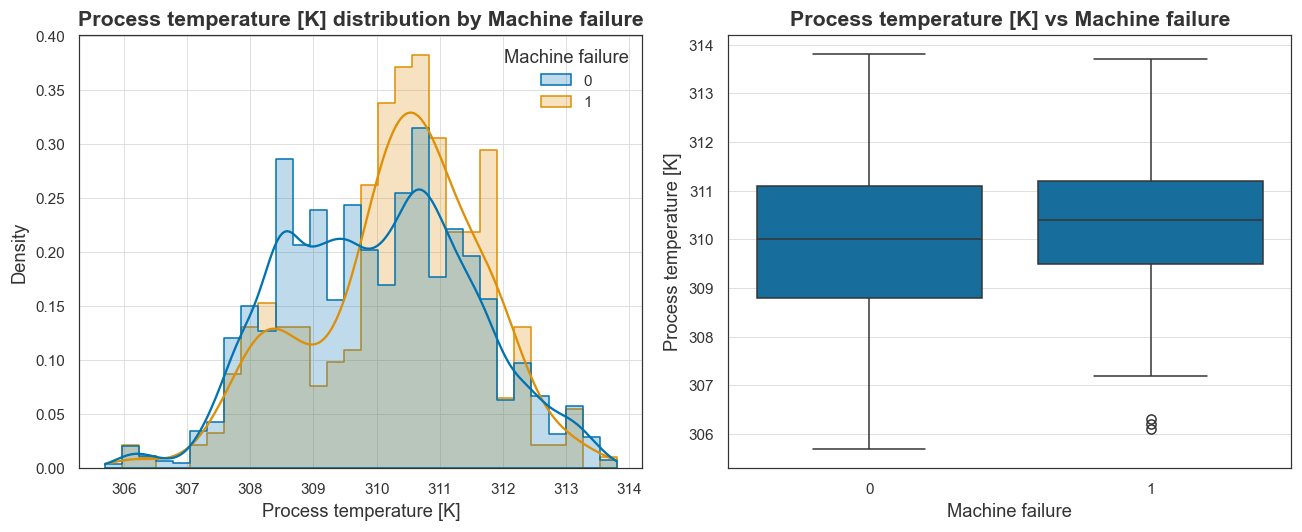

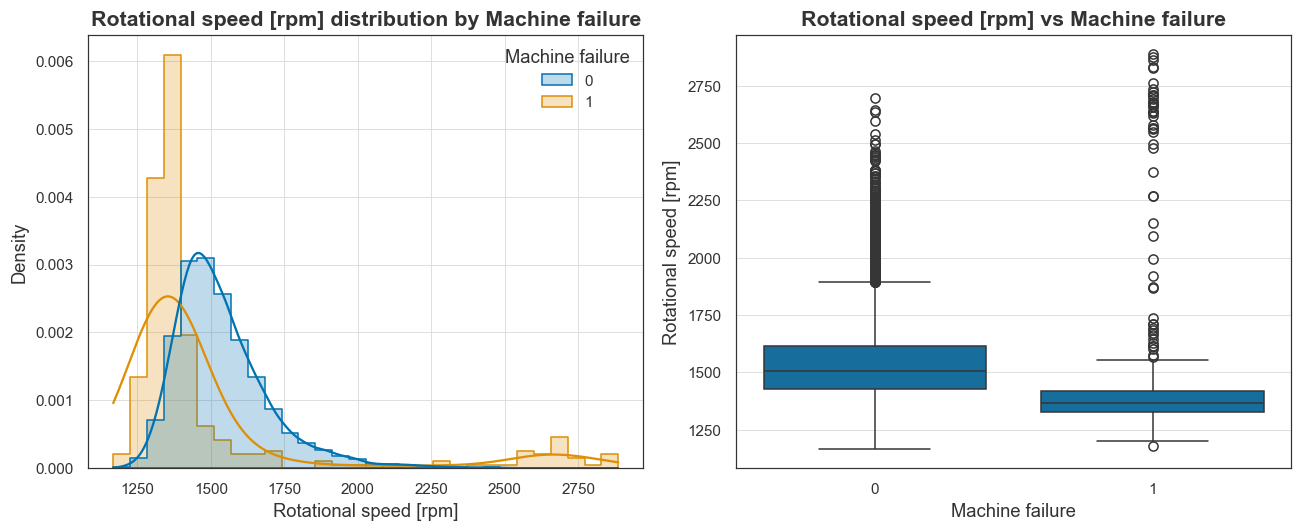

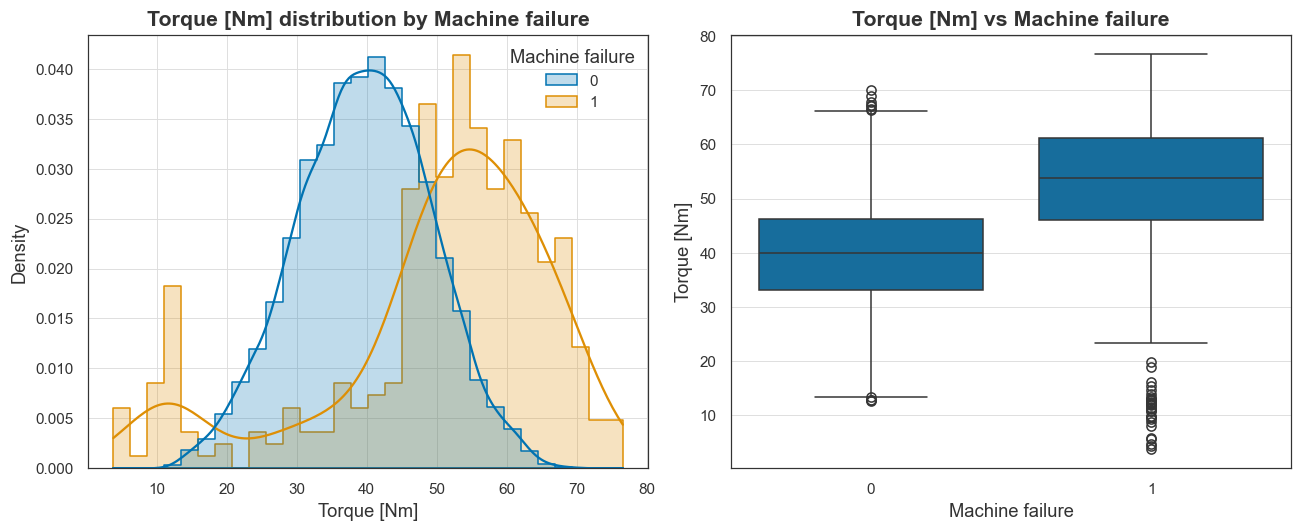

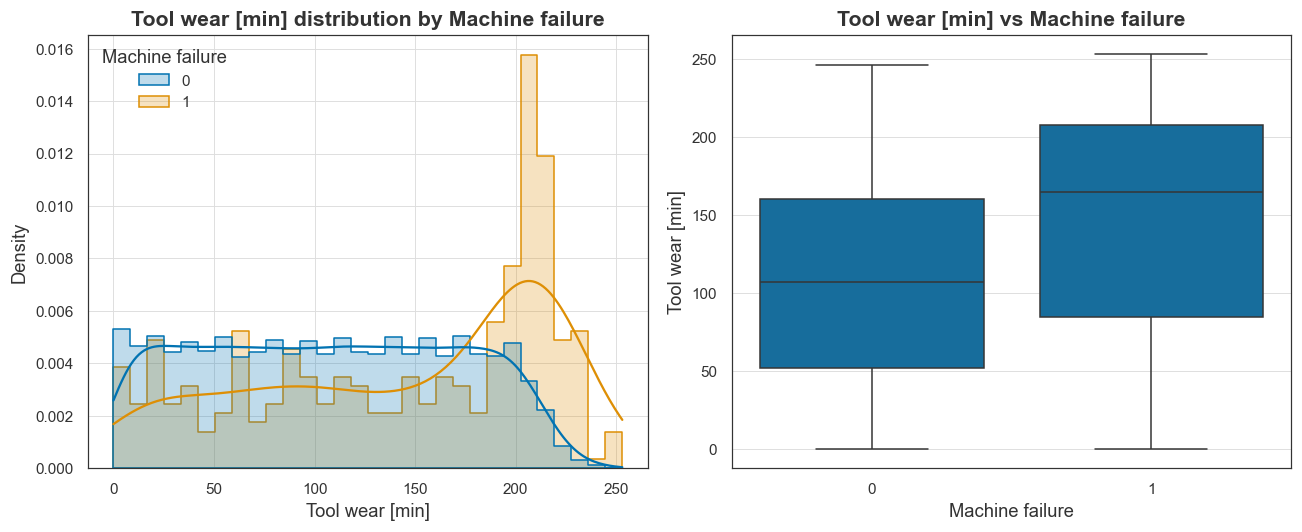

In [193]:
for feature_name in numerical_feature:
    plot_numerical_feature_vs_target(df, feature_name, target_name)

In [194]:
def chi2_feature_target(df, feature, target):
    contingency = pd.crosstab(df[feature], df[target])

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()
    r, k = contingency.shape

    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

    return {
        "chi2_stat": chi2,
        "p_value": p,
        "significant": p < 0.05,
        "cramers_v": v,
        "interpretation": ("weak" if v < 0.1 else "moderate" if v < 0.3 else "strong"),
    }

In [195]:
result = chi2_feature_target(df, categorical_feature[0], target_name)
print("Test Chi2:")
print(f"  chi2_stat: {result['chi2_stat']}")
print(f"  p_value: {result['p_value']}")
print(f"  significant: {result['significant'].astype(bool)}")
print("Intensity:")
print(f"  cramers_v: {result['cramers_v']}")
print(f"  interpretation: {result['interpretation']}")

Test Chi2:
  chi2_stat: 13.75171680114931
  p_value: 0.0010324110359454081
  significant: True
Intensity:
  cramers_v: 0.03708330729742064
  interpretation: weak


In [196]:
def numeric_test(df, feature, target, alpha=0.05, max_sample=5000):
    data = df[[feature, target]].dropna()

    groups = data[target].unique()
    if len(groups) != 2:
        raise ValueError("Target must be binary (0/1).")

    g1, g2 = groups

    x1 = data[data[target] == g1][feature]
    x2 = data[data[target] == g2][feature]

    def sample_if_needed(x):
        if len(x) > max_sample:
            return x.sample(max_sample, random_state=42)
        return x

    x1_s = sample_if_needed(x1)
    x2_s = sample_if_needed(x2)

    s1_stat, s1_p = shapiro(x1_s)
    s2_stat, s2_p = shapiro(x2_s)

    normal_1 = s1_p > alpha
    normal_2 = s2_p > alpha

    lev_stat, lev_p = levene(x1, x2)
    equal_var = lev_p > alpha

    def cohens_d(a, b):
        n1, n2 = len(a), len(b)
        var1, var2 = a.var(ddof=1), b.var(ddof=1)

        pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        return (a.mean() - b.mean()) / pooled_std

    d = cohens_d(x1, x2)

    if normal_1 and normal_2 and equal_var:
        test_used = "t-test (pooled or Welch)"
        stat, p = ttest_ind(x1, x2, equal_var=False)

    else:
        test_used = "mann-whitney"
        stat, p = mannwhitneyu(x1, x2, alternative="two-sided")

    if abs(d) < 0.2:
        effect_size = "weak"
    elif abs(d) < 0.5:
        effect_size = "moderate"
    elif abs(d) < 0.8:
        effect_size = "strong"
    else:
        effect_size = "very strong"

    return {
        "test_used": test_used,
        "p_value": p,
        "significant": p < alpha,
        "normality": {
            str(g1): {"p_value": s1_p, "normal": normal_1},
            str(g2): {"p_value": s2_p, "normal": normal_2},
        },
        "variance_test": {
            "levene_stat": lev_stat,
            "p_value": lev_p,
            "equal_var": equal_var,
        },
        "cohens_d": d,
        "effect_size": effect_size,
        "group_stats": {
            str(g1): {"mean": x1.mean(), "std": x1.std()},
            str(g2): {"mean": x2.mean(), "std": x2.std()},
        },
        "test_result": {"stat": stat, "p_value": p},
    }

In [197]:
for feature_name in numerical_feature:
    result = numeric_test(df, feature_name, target_name)
    print(f"{feature_name}")
    print(f"  test_used: {result['test_used']}")
    print(f"  p_value: {result['p_value']}")
    print(f"  significant: {result['significant'].astype(bool)}")
    print("Intensity:")
    print(f"  cohens_d: {result['cohens_d']}")
    print(f"  effect_size: {result['effect_size']}")
    print()

Air temperature [K]
  test_used: mann-whitney
  p_value: 8.656108133039112e-17
  significant: True
Intensity:
  cohens_d: -0.45769662205287276
  effect_size: moderate

Process temperature [K]
  test_used: mann-whitney
  p_value: 6.486083127989518e-05
  significant: True
Intensity:
  cohens_d: -0.19873606386369788
  effect_size: weak

Rotational speed [rpm]
  test_used: mann-whitney
  p_value: 9.706907631568239e-63
  significant: True
Intensity:
  cohens_d: 0.24438249676886892
  effect_size: moderate

Torque [Nm]
  test_used: mann-whitney
  p_value: 2.262232331232534e-64
  significant: True
Intensity:
  cohens_d: -1.0769742183217652
  effect_size: very strong

Tool wear [min]
  test_used: mann-whitney
  p_value: 2.9164608736257626e-24
  significant: True
Intensity:
  cohens_d: -0.5858858107442972
  effect_size: strong

